In [34]:
import geopandas as gpd

In [35]:
gdf = gpd.read_file("Dataset_Delhi_NCR/delhi_ncr_region.geojson")

gdf

,geometry
0,"POLYGON ((76.85108 28.22115, 76.85219 28.22098..."
1,"POLYGON ((77.15903 29.29436, 77.15999 29.29427..."
2,"MULTIPOLYGON (((77.07565 27.27704, 77.07819 27..."
3,"POLYGON ((77.97073 28.71104, 77.97089 28.71096..."
4,"POLYGON ((77.2143 28.78524, 77.21521 28.78514,..."
5,"POLYGON ((77.39054 28.63475, 77.39107 28.63431..."
6,"POLYGON ((77.45693 28.92601, 77.4587 28.92535,..."
7,"POLYGON ((78.05232 28.88322, 78.05345 28.88317..."
8,"POLYGON ((77.59747 29.25693, 77.59772 29.25677..."
9,"POLYGON ((77.94034 29.71194, 77.94094 29.71084..."


In [36]:
# Data for five large global cities (one from each continent)
data = {
    "Name": ["New York City", "São Paulo", "Tokyo", "Lagos", "Sydney"],
    "Population": [8419600, 12325232, 13929286, 15000000, 5312163],  # Approximate populations
    "Latitude": [40.7128, -23.5505, 35.6895, 6.5244, -33.8688],
    "Longitude": [-74.0060, -46.6333, 139.6917, 3.3792, 151.2093]
}

In [37]:
import pandas as pd

In [38]:
cities_df = pd.DataFrame(data)

In [39]:
gdf = gpd.GeoDataFrame(
    cities_df,
    geometry=gpd.points_from_xy(
        cities_df['Latitude'],
        cities_df['Longitude']
    )
)

<Axes: >

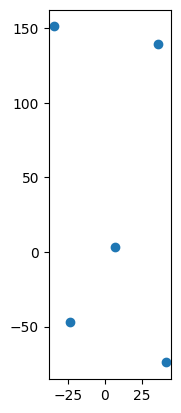

In [40]:
gdf.plot()

In [41]:
gdf.crs


In [42]:
!jupyter trust Q1.ipynb

Notebook already signed: Q1.ipynb


In [54]:
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point

data = {
    "Name": ["New York City", "São Paulo", "Tokyo", "Lagos", "Sydney"],
    "Population": [8419600, 12325232, 13929286, 15000000, 5312163],
    "Latitude": [40.7128, -23.5505, 35.6895, 6.5244, -33.8688],
    "Longitude": [-74.0060, -46.6333, 139.6917, 3.3792, 151.2093]
}

df = pd.DataFrame(data)

gdf = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.Longitude, df.Latitude),
    crs="EPSG:4326"
)


In [58]:
gdf

,Population,Latitude,Longitude,geometry,area
Name,,,,,
New York City,8419600,40.7128,-74.0060,POINT (-74.006 40.7128),0.0
São Paulo,12325232,-23.5505,-46.6333,POINT (-46.6333 -23.5505),0.0
Tokyo,13929286,35.6895,139.6917,POINT (139.6917 35.6895),0.0
Lagos,15000000,6.5244,3.3792,POINT (3.3792 6.5244),0.0
Sydney,5312163,-33.8688,151.2093,POINT (151.2093 -33.8688),0.0


In [59]:

gdf["area"] = gdf.area

C:\Users\Kinjal Chavda\AppData\Local\Temp\ipykernel_20384\3086140819.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'area' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf["area"] = gdf.area


In [45]:
gdf['boundary'] = gdf.boundary
gdf['boundary']

0    GEOMETRYCOLLECTION EMPTY
1    GEOMETRYCOLLECTION EMPTY
2    GEOMETRYCOLLECTION EMPTY
3    GEOMETRYCOLLECTION EMPTY
4    GEOMETRYCOLLECTION EMPTY
Name: boundary, dtype: geometry

In [46]:
gdf['centroid'] = gdf.centroid
gdf['centroid']

C:\Users\Kinjal Chavda\AppData\Local\Temp\ipykernel_20384\3714020261.py:1: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['centroid'] = gdf.centroid


0      POINT (-74.006 40.7128)
1    POINT (-46.6333 -23.5505)
2     POINT (139.6917 35.6895)
3        POINT (3.3792 6.5244)
4    POINT (151.2093 -33.8688)
Name: centroid, dtype: geometry

In [47]:
first_point = gdf['centroid'].iloc[0]
gdf['distance'] = gdf['centroid'].distance(first_point)
gdf['distance']

C:\Users\Kinjal Chavda\AppData\Local\Temp\ipykernel_20384\2530803384.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'distance' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  gdf['distance'] = gdf['centroid'].distance(first_point)


0      0.000000
1     69.850100
2    213.756732
3     84.600921
4    237.243222
Name: distance, dtype: float64

<Axes: >

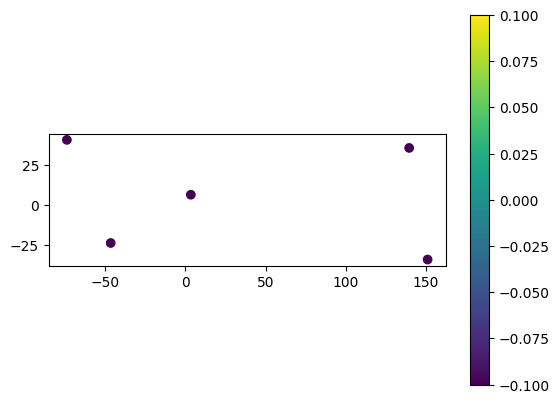

In [48]:
gdf.plot("area", legend=True)